### 1 - Introduction


In [1]:
########################################## Cell 0: Import (un)necessary packages ############################################

#%pip install pandas numpy scipy matplotlib torch torchvision torchaudio scikit-learn

import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import random
from collections import Counter
from sklearn.metrics import r2_score

random.seed(42)
np.random.seed(42)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#To run this outside Leo's computer, change the following ROOT path to where you're storing your files :)
#ROOT = Path.home() /  "Desktop" / "LGundersen" / "Internship_RO"
#ROOT = Path.home() / "OneDrive" / "Ambiente de Trabalho" / "LGundersen" / "Internship_RO"

#To generate new data, change to True
Generate_new_data = True 

mabnames_list = ['Adalimumab']  
#LGnote: 
#dfcoefs contains stoichiometric coefficients and dfinfo contains mAb info and vmaxmab values.
#In this version, when Generate_new_data = False, only vmaxmab values are used. Other values can be used to calculate new
#   vmaxmab values, as seen in Section 2, allowing for the generation of new vmaxmab values and the correspondent coefficents. 
# Additionaly, new mAbs can be added, provided the new mAb sequence is saved in the excel dfinfo.  

### 3 - Kinetics (retrive from Pinto et al. (2022))

In [2]:
######################################### Cell 3A: Define kinetic constants, kinetic equations, growth ############################################

def kinetics(X, mAB, ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL,
             ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, V, t, upars):
    
######################################################### Kinetic constants ##################################################################

     #These values were based on the paper Robitaille et al. (2015): “A Single Dynamic Metabolic Model Can Describe mAb Producing CHO Cell Batch and Fed-Batch Cultures on Different Culture Media,”,
          #but were adapted by J. Pinto to the datasets provided by JSK (previous work).

     #constants
     aAMP = 0.47
     aF6P = 4.1
     bAMP = 10.46
     bF6P = 1.7
     KAAMP = 0.09

     KAF6P = 4.9e-6 / 3.15e-04

     #half-saturation constants
     KdCIT = 7.4e-4  / 3.15e-04
     KdEGLN = 3.5
     KdG6P = 1.710841e-8  / 3.15e-04
     KdLAC = 6.3 
     KdPEP = 3.7e-7  / 3.15e-04
     KdPYR = 4.5e-7  / 3.15e-04
     KdLACg = 170
     KdNH4g = 5.40

     KdALA = 0.1  #mM (Missing from S4)
     
     KmACCOA = 8.6e-7  / 3.15e-04
     KmADP = 7.2e-7  / 3.15e-04
     KmAKG = 1.1e-6  / 3.15e-04
     KmALA = 18
     KmAMP = 2.4e-9  / 3.15e-04
     KmARG = 7.3e-2
     KmASP = 4e-2
     KmASN = 1.2
     KmATP = 1.56e-5  / 3.15e-04
     KmCIT = 1.6e-7  / 3.15e-04
     KmEGLC = 20
     KmEGLN = 2.3
     KmEGLU = 6.6
     KmF6P = 2.6e-6  / 3.15e-04
     KmG6P = 2.866e-8  / 3.15e-04
     KmGAP = 7.8e-7  / 3.15e-04
     KmGLU = 7.5e-5  / 3.15e-04
     KmGLY = 5e-2  / 3.15e-04
     KmHIS = 0.58
     KmILE = 0.038
     KmLAC = 2.9
     KmLEU = 1e-6
     KmLYS = 9.8e-2
     KmMAL = 2.7e-6  / 3.15e-04
     KmNADH = 2.6e-6  / 3.15e-04
     KmNADPH = 8.4e-8  / 3.15e-04
     KmNH4 = 1.1
     KmOXA = 2.2e-7  / 3.15e-04
     KmPEP = 1.7e-7  / 3.15e-04
     KmPYR = 3.9e-6  / 3.15e-04
     KmR5P = 7e-8  / 3.15e-04
     KmSER = 0.22
     KmSUC = 2.3e-7  / 3.15e-04
     KmTYR = 4.8e-2
     KmVAL = 1
     KmX5P = 1.1e-8  / 3.15e-04

     #maximal velocities
     Pratio = 2.1

     VfmaxAK = 1.8e-8  / 3.15e-04
     VrmaxAK = 1.2e-8  / 3.15e-04
     VmaxAKGDH = 2.6e-4  / 3.15e-04
     VfmaxALATA = 1.7e-4  / 3.15e-04
     VrmaxALATA = 2.4e-4  / 3.15e-04
     VmaxASN = 6.2e-6  / 3.15e-04
     VmaxASTA = 7.8e-5  / 3.15e-04
     VmaxATPASE = 9.14e-4  / 3.15e-04
     VmaxCITS = 3.9e-5  / 3.15e-04
     VmaxCS = 8.8e-5  / 3.15e-04
     VmaxEP = 1.3e-5  / 3.15e-04
     VmaxG6PDH = 1.5e-5  / 3.15e-04
     VfmaxGLDH = 1.2e-6  / 3.15e-04
     VrmaxGLDH = 6.3e-5  / 3.15e-04
     VfmaxGLNT = 1.27e-4  / 3.15e-04
     VrmaxGLNT = 1.9e-5  / 3.15e-04
     VfmaxGLUT = 1.8e-6  / 3.15e-04
     VrmaxGLUT = 2.5e-6  / 3.15e-04

     Vmaxgrowth = 6.6e-2

     VmaxHISARGTA = 1.9e-5  / 3.15e-04
     VmaxHK = 6.6e-4  / 3.15e-04
     VfmaxLDH = 1.7e-3  / 3.15e-04
     VrmaxLDH = 5.4e-4  / 3.15e-04
     Vmaxleak = 2.9e-5  / 3.15e-04
     VmaxAATOSUC = 1.3e-4  / 3.15e-04
     VmaxMAB = upars[3]  / 3.15e-04 ##upars[3] = VmaxMAB (See Cell 4A)
     VmaxME = 1.3e-5  / 3.15e-04
     VmaxMLD = 9.5e-5  / 3.15e-04
     VmaxNADPHOX = 1.4e-5  / 3.15e-04
     VmaxPC = 2.1e-4  / 3.15e-04
     VmaxPDH = 7.1e-4  / 3.15e-04
     VmaxPFK = 1.5e-3  / 3.15e-04
     VfmaxPGI = 7.6e-4  / 3.15e-04
     VrmaxPGI = 3.5e-4  / 3.15e-04
     VmaxPGK = 1.065e-3  / 3.15e-04
     VmaxPK = 1.376e-3  / 3.15e-04
     VmaxPPRIBP = 2.6e-9  / 3.15e-04
     Vmaxresp = 0.0032  / 3.15e-04
     VmaxSDH = 4e-4  / 3.15e-04
     VmaxSDHH = 8.5e-6  / 3.15e-04
     VmaxTK = 2.3e-5  / 3.15e-04

     #half-saturation constants
     KmALAg = 7.6e-2 #mM
     KmARGg = 1.5e-2 #mM
     KmASNg = 4.2e-3  #mM
     KmASPg = 1e-2  #mM
     KmATPg = 1.4e-7 #mM
     KmCITg = 3.5e-9  / 3.15e-04  #mmol.10-6cells
     KmCYSg = 1e-3 #mM
     KmEGLNg = 1.4e-3 #mM
     KmG6Pg = 9.9e-13  / 3.15e-04 #mmol.10-6cells
     KmEGLUg = 1.7e-6   #/ 3.15e-04 #mmol.10-6cells #mM #LGnote: unit question
     KmGLYg = 1e-2 #mM
     KmHISg = 1.7e-2 #mM
     KmILEg = 1e-2 #mM
     KmLYSg = 2.7e-2 #mM
     KmMETg = 3.5e-2 #mM
     KmPHEg = 1.6e-2 #mM
     KmPROg = 1e-2 #mM
     KmR5Pg = 1.1e-10 / 3.15e-04 #mmol.10-6cells
     KmSERg = 1.1e-3 #mM
     KmTHRg = 9.6e-3 #mM
     KmTYRg = 1.2e-2 #mM
     KmVALg = 1.3e-3 #mM
     KmALAMAB = 0.13 #mM
     KmARGMAB = 6.2e-2 #mM
     KmASNMAB = 1.4e-6 #mM
     KmASPMAB = 5.6e-2 #mM
     KmATPMAB = 1.1e-7 #mM
     KmCYSMAB = 1e-3 #mM
     KmEGLNMAB = 1.3e-3 #mM
     KmEGLUMAB = 0.22 #/ 3.15e-04 #mmol.10-6cells #mM #LGnote: unit question
     KmGLYMAB = 5e-2 #mM
     KmHISMAB = 5.7e-2 #mM
     KmILEMAB = 8.3e-2 #mM
     KmLEUMAB = 1e-6  #mM
     KmLYSMAB = 5e-2 #mM
     KmMETMAB = 8e-2 #mM
     KmPHEMAB = 7.1e-2 #mM
     KmPROMAB = 1.1e-2 #mM
     KmSERMAB = 1e-3 #mM
     KmTHRMAB = 6.6e-2 #mM
     KmTYRMAB = 9.8e-2 #mM
     KmVALMAB = 7.4e-2 #mM
     KmADPATP = 0.569423 
     KmATPADP = 0.091 
     KmNADNADH = 4.8e-2 
     KmNADHNAD = 0.3 
     KmNADPNADPH = 2 

     kdMin=2.6e-6  #h-1
     kdMax=3.3e-3  #h-1
     BB = 1e-3  #h-1
     K_bNAD=1e-5 / 3.15e-04
     keq_NAD=1e-5 / 3.15e-04
     K_bAMP=1e-5 / 3.15e-04
     keq_AMP=1e-4 / 3.15e-04
     K_bNADP=1e-5 / 3.15e-04
     keq_NADP=1e-5 / 3.15e-04
     keq_AK=10 / 3.15e-04
     km_AK=1e-6 / 3.15e-04
     VrmaxTHDR=2e-7 #mmol.10-6cells.h-1
     km_THDR=1 / 3.15e-04
     Km_TYR_VAA=2 / 3.15e-04
     vrmaxPYRT=3e-6 / 3.15e-04 #mmol.10-6cells.h-1
     k_EPYR=5e-3 
     k_PYR=4e-7 / 3.15e-04 

######################################################### Kinetic equations ##################################################################

     #rate equations
     # Hexokinase
     e1 = EGLC * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmEGLC * (1 + (AMP / ATP) / KAAMP)
     e3 = EGLC * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (ATP / ADP) / (KmATPADP + (ATP / ADP))
     e5 = EGLC / (KmEGLC + EGLC)
     e6 = KdG6P / (KdG6P + G6P)
     VHK = VmaxHK * (e1 / (e2 + e3)) * e4 * e5 * e6

     # Phosphoglucose isomerase
     VPGI = VfmaxPGI * (G6P / (KmG6P + G6P)) * (KdPEP / (KdPEP + PEP)) - VrmaxPGI * (F6P / (KmF6P + F6P))

     # Phosphofructokinase
     e1 = F6P * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmF6P * (1 + (AMP / ATP) / KAAMP)
     e3 = F6P * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (ATP / ADP) / (KmATPADP + (ATP / ADP))
     e5 = KdLAC / (KdLAC + LAC)
     VPFK = VmaxPFK * (e1 / (e2 + e3)) * e4 * e5

     # Phosphoglycerate kinase
     VPGK = VmaxPGK * (GAP / (KmGAP + GAP)) * ((ADP / ATP) / (KmADPATP + (ADP / ATP))) * ((NAD / NADH) / (KmNADNADH + (NAD / NADH)))

     # Pyruvate kinase
     e1 = PEP * (1 + (bF6P * F6P) / (aF6P * KAF6P))
     e2 = KmPEP * (1 + F6P / (KAF6P))
     e3 = F6P * (1 + F6P / KAF6P)
     e4 = (ADP / ATP) / (KmADPATP + (ADP / ATP))
     e5 = KdALA / (KdALA + ALA)
     VPK = VmaxPK * (e1 / (e2 + e3)) * e4 * e5

     # Lactate dehydrogenase
     e1 = PYR * (1 + (bAMP * AMP / ATP) / (aAMP * KAAMP))
     e2 = KmPYR * (1 + (AMP / ATP) / KAAMP)
     e3 = PYR * (1 + (AMP / ATP) / (aAMP * KAAMP))
     e4 = (NADH / NAD) / (KmNADHNAD + (NADH / NAD))
     e5 = LAC / (KmLAC + LAC)
     e6 = (NAD / NADH) / (KmNADNADH + (NAD / NADH))
     e7 = KdPYR / (KdPYR + PYR)
     
     VLDH = VfmaxLDH * (e1 / (e2 + e3)) * e4 - VrmaxLDH * e5 * e6 * e7

     # Glucose-6-phosphate dehydrogenase
     VG6PDH = VmaxG6PDH * G6P / (KmG6P + G6P) * (NADP / NADPH) / (KmNADPNADPH + (NADP / NADPH))

     # Enolase
     VEP = VmaxEP * R5P / (KmR5P + R5P)

     # Transketolase
     VTK = VmaxTK * R5P / (KmR5P + R5P) * X5P / (KmX5P + X5P)

     # Pyruvate dehydrogenase
     VPDH = VmaxPDH * PYR / (KmPYR + PYR) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Citrate synthase
     VCS = VmaxCS * OXA / (KmOXA + OXA) * ACCOA / (KmACCOA + ACCOA)

     # Citrate lyase
     VCITS = VmaxCITS * CIT / (KmCIT + CIT) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # α-Ketoglutarate dehydrogenase
     VAKGDH = VmaxAKGDH * AKG / (KmAKG + AKG) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Succinate dehydrogenase
     VSDH = VmaxSDH * SUC / (KmSUC + SUC) * (NAD / NADH) / (KmNADNADH + (NAD / NADH)) * (ADP / ATP) / (KmADPATP + (ADP / ATP))

     # Malate dehydrogenase
     VMLD = VmaxMLD * MAL / (KmMAL + MAL) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Pyruvate carboxylase
     VPC = VmaxPC * PYR / (KmPYR + PYR) * (ADP / ATP) / (KmADPATP + (ADP / ATP))

     # Malic enzyme
     VME = VmaxME * MAL / (KmMAL + MAL) * (NAD / NADH) / (KmNADNADH + (NAD / NADH))

     # Glutamine transporter
     VGLNT = VfmaxGLNT*0.1 * EGLN / (KmEGLN + EGLN)* (ATP/ADP) / (KmATPADP + (ATP/ADP)) - VrmaxGLNT * GLU / (KmGLU + GLU) * (ADP/ATP) / (KmADPATP + (ADP/ATP)) * NH4/(KmNH4 + NH4)

     # Glutamate dehydrogenase
     VGLDH = VfmaxGLDH * GLU / (KmGLU + GLU) * (NAD / NADH) / (KmNADNADH + (NAD / NADH)) - VrmaxGLDH * AKG / (KmAKG + AKG) * (NADH / NAD) / (KmNADHNAD + (NADH / NAD)) * KmNH4/(KmNH4 + NH4)

     # Alanine transaminase
     VALATA = VfmaxALATA * GLU / (KmGLU + GLU) * PYR / (KmPYR + PYR) - VrmaxALATA * ALA / (KmALA + ALA) * AKG / (KmAKG + AKG) * KdEGLN / (KdEGLN + EGLN)

     # Asparagine synthetase
     VASN = VmaxASN * ASN / (KmASN + ASN)

     # Aspartate transaminase
     VASTA = VmaxASTA * AKG / (KmAKG + AKG) * ASP / (KmASP + ASP)

     # Amino acid transporter to succinate
     VAATOSUC = 0.05*VmaxAATOSUC * LYS /(KmLYS + LYS) * ILE / (KmILE + ILE) * AKG / (KmAKG + AKG) * VAL / (KmVAL + VAL) * (NAD/NADH) / (KmNADNADH + (NAD/NADH)) * (NADP/NADPH) / (KmNADPNADPH + (NADP/NADPH)) * (ATP/ADP) / (KmATPADP + (ATP/ADP))*TYR / (Km_TYR_VAA + TYR);#clo

     # Histidine-arginine transaminase
     VHISARGTA = VmaxHISARGTA * HIS / (KmHIS + HIS) * ARG / (KmARG + ARG) * LEU / (KmLEU + LEU) * AKG / (KmAKG + AKG)

     # Glutamate transporter
     VGLUT = VfmaxGLUT * GLU / (KmGLU + GLU) - VrmaxGLUT * EGLU / (KmEGLU + EGLU)

     # Serine dehydratase
     VSDHH = VmaxSDHH * SER / (KmSER + SER)

     # ATPase
     VATPASE = VmaxATPASE * ATP / (KmATP + ATP)

     # NADPH oxidase
     VNADPHOX = VmaxNADPHOX * NADPH / (KmNADPH + NADPH)

     # Respiration
     VRESP = Vmaxresp * (ADP / ATP) / (KmADPATP + (ADP / ATP)) * NADH / (KmNADH + NADH)

     # NADH leak
     VLEAK = Vmaxleak * NADH / (KmNADH + NADH)

     # Adenylate kinase
     VAK = 1e3 * VfmaxAK * (AMP - ADP / keq_AK) / (km_AK + AMP + ADP / keq_AK)  # simplified

     # Pentose phosphate ribose
     VPPRIBP = VmaxPPRIBP * R5P / (KmR5P + R5P) * EGLN / (KmEGLN + EGLN) * ASP / (KmASP + ASP) * GLY / (KmGLY + GLY) * ATP / (KmATP + ATP)

########################################################### Growth ##################################################################

     #define growth
     #growth is affected by concentrations of aminoacids
     MU = Vmaxgrowth * (G6P / (KmG6Pg + G6P)) * (R5P / (KmR5Pg + R5P)) * (LYS / (KmLYSg + LYS)) * (CIT / (KmCITg + CIT)) * (ILE / (KmILEg + ILE)) * (VAL / (KmVALg + VAL)) * (TYR / (KmTYRg + TYR)) * (ASN / (KmASNg + ASN)) * (ASP / (KmASPg + ASP)) * (ALA / (KmALAg + ALA)) * (ARG / (KmARGg + ARG)) * (EGLN / (KmEGLNg + EGLN)) * (EGLU / (KmEGLUg + EGLU)) * (GLY / (KmGLYg + GLY)) * (HIS / (KmHISg + HIS)) * (PHE / (KmPHEg + PHE)) * (PRO / (KmPROg + PRO)) * (THR / (KmTHRg + THR)) * (KdLACg / (KdLACg + LAC)) * (KdNH4g / (KdNH4g + NH4))* (ATP / (KmATPg + ATP))  #closed.  #mmol.10-6cells.h-1 

     #effect of induction on Vmaxmab
     Tind=upars[2] #upars[2] = T_ind (See Cell 4A)

     #define vmab 
     if t>Tind: #after induction mAb production is induced
          #mAb velocity is affected by the concentration of aminoacids and correspondent half-saturation constants
          VMAB = 0.35 * VmaxMAB * (LYS / (KmLYSMAB + LYS)) * (ILE / (KmILEMAB + ILE)) * (VAL / (KmVALMAB + VAL)) * (TYR / (KmTYRMAB + TYR)) * (ASN / (KmASNMAB + ASN)) * (ASP / (KmASPMAB + ASP)) * (ALA / (KmALAMAB + ALA)) * (ARG / (KmARGMAB + ARG)) * (EGLN / (KmEGLNMAB + EGLN)) * (EGLU / (KmEGLUMAB + EGLU)) * (GLY / (KmGLYMAB + GLY)) * (HIS / (KmHISMAB + HIS)) * (PHE / (KmPHEMAB + PHE)) * (PRO / (KmPROMAB + PRO)) * (THR / (KmTHRMAB + THR)) * (ATP / (KmATPMAB + ATP)) #closed.  #mmol.10-6cells.h-1
          #Vmaxgrowth = Vmaxgrowth/2
     else:      #before induction Vmaxmab is minimal
          VMAB=1e-12
          
     #establish death that is affected by biomass concentration
     #KdX=kdMin + kdMax*(X/(X+7.5))
     KdX=kdMin + kdMax*(BB/(BB+MU))**2

     NADbasal=K_bNAD * MU/Vmaxgrowth*(1-NAD/(keq_NAD))
     NADPbasal=K_bNADP * MU/Vmaxgrowth*(1-NADP/(keq_NADP))
     AMPbasal=K_bAMP * MU/Vmaxgrowth*(1-AMP/(keq_AMP))
     THDR=VrmaxTHDR*THR/(km_THDR+km_THDR)*(NAD/NADH)   #LGNote: wrong equation?
     VPYRT=vrmaxPYRT*EPYR/(1+EPYR+k_EPYR)*k_PYR/(k_PYR+PYR)

     VHK=VHK*MU/Vmaxgrowth+(-0.071*0.5-0.076*0.5)/-0.364*6.8333e-05/3.15e-04 #LGnote corrected

     Feed=[]

     #return all fluxes and key intermediates
     return (VHK, VPGI, VPFK, VPGK, VPK, VLDH, VG6PDH, VEP, VTK, VPDH, VCS, VCITS, VAKGDH, VSDH, VMLD, VPC, VME, VGLNT, VGLDH, VALATA, VASN, VASTA, VAATOSUC, VHISARGTA, VGLUT, VSDHH, VATPASE, VNADPHOX, VRESP, VLEAK, VAK, VPPRIBP, MU, VMAB, KdX, NADbasal,NADPbasal,AMPbasal,THDR,VPYRT)


### 4 - ODEs (retrive from Pinto et al. (2022))

In [3]:
######################################### Cell 4A: Establish ODE system ################################################

#define differential equations
def ode(t,state, upars):
  #ACCOA ADP  AKG AMP ATP CIT F6P G6P GAP GLU MAL NAD NADH NADP NADPH OXA PEP PYR R5P SUC X5P || ALA ARG ASN ASP CYS EGLC EGLN EGLU EPYR GLY HIS ILE LAC LEU LYS MET NH4 PHE PRO SER THR TYR VAL mAB  X || V
                                      
  #extract states
  ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL, mAB, X, V = state[21:47] #extracellular + product + biomass + volume
  ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P = state[:21]                      #intracellular

  #receive reaction rates using the kinetics function defined in Cell 2A
  kinetics_out = kinetics(X, mAB, ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL,
                          ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, 
                          V, t, upars)

  #unpack values obtained
  (VHK, VPGI, VPFK, VPGK, VPK, VLDH, VG6PDH, VEP, VTK, VPDH, VCS, VCITS, VAKGDH, VSDH, VMLD, VPC, VME, VGLNT, VGLDH, VALATA, VASN, VASTA, VAATOSUC, VHISARGTA, VGLUT, VSDHH, VATPASE, VNADPHOX, VRESP, VLEAK, VAK, VPPRIBP, MU, VMAB, KdX, NADbasal,NADPbasal,AMPbasal,THDR,VPYRT) = kinetics_out 

  #upars is composed of DoE (Pre_ind, Pos_ind, T_ind) + Vmaxmab + coefficients 
  [Feed1,Feed2,tind,VmaxMAB] = upars[0:4]

  #establish feed pre and post induction
  if t<tind:
    Feed = Feed1
  else:
    Feed = Feed2

  #establish concentrations of feed components
  #           ALA,  ARG,  ASN,  ASP,  CYS,  AGLC,  EGLN, EGLU, EPYR,  GLY,  HIS, ILE,  LAC, LEU,  LYS,  MET, NH4, PHE,  PRO,  SER,  THR,  TYR, VAL, 
  feed_conc= [00.0, 29.71, 0.0, 0.0, 3.32, 1892.8, 23.53, 0.0, 39.67, 0.0, 11.73, 46.96, 0.0, 27.71, 1.02, 3.57, 0.0, 23.89, 41.31, 72.97, 32.12, 0.0, 56.21]

  #initialize feed mass at 0
  Feed_mass = np.zeros(46)
  
  #for each element, the mass added (mmol/h) is equal to the  feed rate (L/h) * concentration (mmol/L) 
  for e in range(0,len(feed_conc)):
    Feed_mass[e]=Feed*feed_conc[e]

  #dillution rate (/h) is feed rate (L/h) / volume (L)
  D = Feed/V

  #stoichiometry ODEs 
  #initiallize ODE system
  ODEs = np.zeros(72)

  PO=2.5

  #internal stoichiometry
  ODEs[0]= VPDH - VCS + 8*VAATOSUC+ THDR   - MU*ACCOA                                                                                                 #ACCOA
  ODEs[1]= VHK + VPFK - VPGK - VPK - VSDH + VPC - VGLNT + VAATOSUC + VATPASE - 2*PO*VRESP + 2*VAK + 2*VPPRIBP + 6.53e-3*MU + 0.0274197702386725*VMAB - MU*ADP  #ADP 
  ODEs[2]= VCITS - VAKGDH + VGLDH + VALATA - VASTA -7*VAATOSUC - VHISARGTA - MU*AKG                                                                   #AKG
  ODEs[3]= - VAK + VPPRIBP+AMPbasal - MU*AMP                                                                                                          #AMP  
  ODEs[4]= -VHK - VPFK + VPGK + VPK + VSDH - VPC + VGLNT - VAATOSUC - VATPASE + 2*PO*VRESP - VAK -2*VPPRIBP -6.53e-3*MU -0.0274197702386725*VMAB    -MU*ATP    #ATP
  ODEs[5]= VCS - VCITS - 8.64e-5*MU -MU*CIT                                                                                                           #CIT 
  ODEs[6]= VPGI - VPFK + 2*VTK -MU*F6P                                                                                                                #F6P
  ODEs[7]= VHK - VPGI - VG6PDH -5.5e-6*MU -MU*G6P                                                                                                     #G6P
  ODEs[8]= 2*VPFK - VPGK + VTK  -MU*GAP                                                                                                               #GAP
  ODEs[9]= VGLNT - VGLDH - VALATA + VASTA + 4*VAATOSUC + 4*VHISARGTA - VGLUT -MU*GLU                                                                  #GLU
  ODEs[10]= VSDH - VMLD -VME + VAATOSUC + 2*VPPRIBP -MU*MAL                                                                                           #MAL
  ODEs[11]= - VPGK + VLDH - VPDH - VCITS - VAKGDH - 2*VSDH/3 - VMLD - VME - VGLDH -9*VAATOSUC + 2*VRESP + 2*VLEAK+NADbasal-THDR -MU*NAD               #NAD
  ODEs[12]= VPGK - VLDH + VPDH + VCITS + VAKGDH + 2*VSDH/3 + VMLD + VME + VGLDH + 9*VAATOSUC - 2*VRESP - 2*VLEAK+THDR -MU*NADH                        #NADH
  ODEs[13]= - 2*VG6PDH - 2*VAATOSUC + VNADPHOX+NADPbasal -MU*NADP                                                                                     #NADP
  ODEs[14]= 2*VG6PDH + 2*VAATOSUC - VNADPHOX -MU*NADPH                                                                                                #NADPH
  ODEs[15]= - VCS + VMLD + VPC + VASTA -MU*OXA                                                                                                        #OXA
  ODEs[16]= VPGK - VPK -MU*PEP                                                                                                                        #PEP
  ODEs[17]= VPK - VLDH - VPDH - VPC + VME - VALATA + VSDHH+VPYRT -MU*PYR                                                                              #PYR
  ODEs[18]= VG6PDH - VEP - VTK - 0.6*VPPRIBP -2.63e-5*MU -MU*R5P                                                                                      #R5P
  ODEs[19]= VAKGDH - VSDH + 3*VAATOSUC -MU*SUC                                                                                                        #SUC
  ODEs[20]= VEP - 2*VTK -MU*X5P 

  #external stoichiometry
  ODEs[21]= (VALATA   -0.000103340842608062*VMAB      -9.70e-5*MU)*X  -D*ALA     + Feed_mass[0]/V                                                              #ALA #A
  ODEs[22]= (-VHISARGTA  -0.0000620045055648374*VMAB   -5.34e-5*MU)*X         - D*ARG  + Feed_mass[1]/V                                                         #ARG #R
  ODEs[23]= (-VASN  -0.000048225726550429*VMAB        -4.51e-5*MU)*X                -D*ASN + Feed_mass[2]/V                                                    #ASN #N
  ODEs[24]= (VASN - VASTA -2*VPPRIBP  -0.0000620045055648374*VMAB -5.57e-5*MU)*X  -D*ASP + Feed_mass[3]/V                                                       #ASP #D
  ODEs[25]= (-0.0000344469475360207*VMAB -1.8e-5*MU)*X        -D*CYS         + Feed_mass[4]/V                                                                   #CYS #C
  ODEs[26]= ( -VHK)*X                    -D*EGLC           + Feed_mass[5]/V                                                                       #EGLC
  ODEs[27]= (-VGLNT -2*VPPRIBP  -0.000103340842608062*VMAB -7.63e-5*MU)*X   -D*EGLN    + Feed_mass[6]/V                                                        #EGLN #Q
  ODEs[28]= (VGLUT  -0.0000620045055648374*VMAB -6.55e-5*MU)*X  -D*EGLU        + Feed_mass[7]/V                                                                 #EGLU #E
  ODEs[29]= (-VPYRT)*X     -D*EPYR                               + Feed_mass[8]/V                                                                 #EPYR
  ODEs[30]= (+THDR-VPPRIBP + 2*VPPRIBP  -0.000089562063593654*VMAB -1.03e-4*MU)*X   -D*GLY   + Feed_mass[9]/V                                                  #GLY #G
  ODEs[31]= (-VHISARGTA   -0.0000137787790144083*VMAB   -2.08e-5*MU)*X    -D*HIS  + Feed_mass[10]/V                                                             #HIS #H
  ODEs[32]= (-VAATOSUC  -0.000048225726550429*VMAB -4.76e-5*MU)*X   -D*ILE    + Feed_mass[11]/V                                                                #ILE #I
  ODEs[33]= (VLDH)*X      -D*LAC                                + Feed_mass[12]/V                                                                 #LAC
  ODEs[34]= (-VAATOSUC -0.000103340842608062*VMAB -9.23e-5*MU)*X   -D*LEU    + Feed_mass[13]/V                                                                 #LEU #L
  ODEs[35]= (-VAATOSUC  -0.000089562063593654*VMAB -8.35e-5*MU)*X      -D*LYS   + Feed_mass[14]/V                                                              #LYS #K
  ODEs[36]=  ( -6.88938950720415E-06*VMAB  -2.28e-5*MU)*X      -D*MET           + Feed_mass[15]/V                                                              #MET #M
  ODEs[37]= (VGLNT + VGLDH + VASN + VHISARGTA + VSDHH)*X     -D*NH4 + Feed_mass[16]/V                                                             #NH4
  ODEs[38]=   (-0.000048225726550429*VMAB -4.04e-5*MU)*X      -D*PHE     + Feed_mass[17]/V                                                                     #PHE #F
  ODEs[39]=  (-0.0000757832845792457*VMAB -4.80e-5*MU)*X     -D*PRO      + Feed_mass[18]/V                                                                      #PRO  #P
  ODEs[40]=  (-VSDHH   -0.000206681685216124*VMAB -6.98e-5*MU)*X    -D*SER  + Feed_mass[19]/V                                                                  #SER  #S
  ODEs[41]=   ( -THDR-0.000124009011129674*VMAB  -5.52e-5*MU)*X   -D*THR      + Feed_mass[20]/V                                                                #THR  #T
  ODEs[42]= (-VAATOSUC  -0.0000137787790144083*VMAB -2.84e-5*MU)*X  -D*TYR    + Feed_mass[21]/V                                                                 #TYR  #W
  ODEs[43]= (-VAATOSUC  -0.000103340842608062*VMAB -6.97e-5*MU)*X   -D*VAL    + Feed_mass[22]/V                                                                #VAL  #V
  ODEs[44]= VMAB*X       -D*mAB                                                                                                                   #mAB
  ODEs[45]= (MU -KdX)*X    -D*X                                                                                                                       #X

  #feed rate
  ODEs[46]= Feed

  #reacted amounts for external components
  ODEs[47]= (VALATA   -0.000103340842608062*VMAB      -9.70e-5*MU)*X*V                                                                                         #ALA #A
  ODEs[48]= (-VHISARGTA  -0.0000620045055648374*VMAB   -5.34e-5*MU)*X*V                                                                                         #ARG #R
  ODEs[49]= (-VASN  -0.000048225726550429*VMAB        -4.51e-5*MU)*X*V                                                                                         #ASN #N
  ODEs[50]= (VASN - VASTA -2*VPPRIBP  -0.0000620045055648374*VMAB -5.57e-5*MU)*X*V                                                                              #ASP #D
  ODEs[51]= (-0.0000344469475360207*VMAB -1.8e-5*MU)*X *V                                                                                                       #CYS #C
  ODEs[52]= ( -VHK)*X     *V                                                                                                                      #EGLC
  ODEs[53]= (-VGLNT -2*VPPRIBP  -0.000103340842608062*VMAB -7.63e-5*MU)*X *V                                                                                   #EGLN #Q
  ODEs[54]= (VGLUT  -0.0000620045055648374*VMAB -6.55e-5*MU)*X  *V                                                                                              #EGLU #E
  ODEs[55]= (-VPYRT)*X       *V                                                                                                                   #EPYR
  ODEs[56]= (+THDR-VPPRIBP + 2*VPPRIBP  -0.000089562063593654*VMAB -1.03e-4*MU)*X *V                                                                           #GLY #G
  ODEs[57]= (-VHISARGTA   -0.0000137787790144083*VMAB   -2.08e-5*MU)*X*V                                                                                        #HIS #H
  ODEs[58]= (-VAATOSUC  -0.000048225726550429*VMAB -4.76e-5*MU)*X   *V                                                                                         #ILE #I
  ODEs[59]= (VLDH)*X                     *V                                                                                                       #LAC
  ODEs[60]= (-VAATOSUC -0.000103340842608062*VMAB -9.23e-5*MU)*X *V                                                                                            #LEU #L
  ODEs[61]= (-VAATOSUC  -0.000089562063593654*VMAB -8.35e-5*MU)*X  *V                                                                                          #LYS #K
  ODEs[62]=  ( -6.88938950720415E-06*VMAB  -2.28e-5*MU)*X     *V                                                                                               #MET #M
  ODEs[63]= (VGLNT + VGLDH + VASN + VHISARGTA + VSDHH)*X    *V                                                                                    #NH4
  ODEs[64]=   (-0.000048225726550429*VMAB -4.04e-5*MU)*X *V                                                                                                    #PHE #F
  ODEs[65]=  (-0.0000757832845792457*VMAB -4.80e-5*MU)*X *V                                                                                                     #PRO  #P
  ODEs[66]=  (-VSDHH   -0.000206681685216124*VMAB -6.98e-5*MU)*X *V                                                                                            #SER  #S
  ODEs[67]=   ( -THDR-0.000124009011129674*VMAB  -5.52e-5*MU)*X *V                                                                                             #THR  #T
  ODEs[68]= (-VAATOSUC  -0.0000137787790144083*VMAB -2.84e-5*MU)*X   *V                                                                                         #TYR  #W
  ODEs[69]= (-VAATOSUC  -0.000103340842608062*VMAB -6.97e-5*MU)*X  *V                                                                                          #VAL  #V
  ODEs[70]= VMAB*X *V                                                                                                                             #mAb                    
  ODEs[71]= (MU -KdX)*X *V                                                                                                                            #X

  return ODEs

In [4]:
######################################### Cell 4B: Define time span and initial concentrations ################################################

#define constants and time spans (x axis in h)
time_span = (0, 240)
t_points = np.linspace(0, 240, 21) 

#define initial values
#          ACCOA               ADP                  AKG                  AMP                  ATP                  CIT                  F6P                  G6P                  GAP                  GLU                  MAL                  NAD                  NADH                 NADP                 NADPH                OXA                  PEP                  PYR                  R5P                  SUC                  X5P                   ||   ALA              ARG              ASN              ASP              CYS              EGLC             EGLN             EGLU              EPYR              GLY               HIS              ILE              LAC              LEU              LYS              MET              NH4              PHE              PRO              SER              THR              TYR              VAL                mAB  X  ||   V  |       (reacted amounts are 0 in the begining)
x_init = [ 0.00440000000000000,6.70000000000000e-05,1.90000000000000e-07,3.10000000000000e-07,7.00000000000000e-06,0.000600000000000000,4.20000000000000e-08,5.60000000000000e-08,4.00000000000000e-07,0.000220000000000000,1.50000000000000e-06,8.90000000000000e-06,7.50000000000000e-07,9.50000000000000e-07,9.30000000000000e-07,2.00000000000000e-07,8.80000000000000e-07,5.00000000000000e-07,2.40000000000000e-08,8.00000000000000e-08,3.00000000000000e-09,      1.11000000000000,6.06000000000000,11.1700000000000,4.47000000000000,2.50000000000000,72.5500000000000,6.21000000000000,0.970000000000000,0.230000000000000,0.650000000000000,1.50000000000000,8.17000000000000,5.22000000000000,10.8400000000000,5.75000000000000,2.23000000000000,2.12000000000000,3.42000000000000,8.98000000000000,10.7000000000000,5.20000000000000,2.32000000000000,7.62000000000000,  0,   4 * 0.315,      270, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
print(x_init[20])
x_init[:20] = [v / 3.15e-04 for v in x_init[:20]] #unit correction for intracellular


3e-09


### 5 - Data generation

In [5]:
######################################### Cell 5A: Data generation with noise ################################################

#establish the noise level
NOISE_LEVEL = 0.10   
rng = np.random.default_rng()

#add 10% of the measured value to each sample
def add_noise(values, noise_level=0.1, rng=rng):
    std = noise_level * np.abs(values)
    noise = rng.normal(0.0, std)
    noisy = values + noise
    return np.clip(noisy, 0.0, None)

#define labels for all components
state_labels = [
    "ACCOA(mmol.10-6cells)","ADP(mmol.10-6cells)","AKG(mmol.10-6cells)", "AMP(mmol.10-6cells)","ATP(mmol.10-6cells)","CIT(mmol.10-6cells)",
    "F6P(mmol.10-6cells)","G6P(mmol.10-6cells)","GAP(mmol.10-6cells)", "GLU(mmol.10-6cells)","MAL(mmol.10-6cells)","NAD(mmol.10-6cells)",
    "NADH(mmol.10-6cells)","NADP(mmol.10-6cells)","NADPH(mmol.10-6cells)", "OXA(mmol.10-6cells)","PEP(mmol.10-6cells)","PYR(mmol.10-6cells)",
    "R5P(mmol.10-6cells)","SUC(mmol.10-6cells)","X5P(mmol.10-6cells)", "ALA(mM)","ARG(mM)","ASN(mM)","ASP(mM)","CYS(mM)",
    "EGLC(mM)","EGLN(mM)","EGLU(mM)","EPYR(mM)","GLY(mM)", "HIS(mM)","ILE(mM)","LAC(mM)","LEU(mM)","LYS(mM)",
    "MET(mM)","NH4(mM)","PHE(mM)","PRO(mM)","SER(mM)", "THR(mM)","TYR(mM)","VAL(mM)","mAB(mg/L)","X(Mcells/mL)"]

if Generate_new_data == True:
    #generate datasets for all mAbs
    for mabname in mabnames_list:
        print(f"\n ############################### {mabname} ########################### \n")

        #retrieve vmaxmab value for each model
        VmaxMAB = 0.01501 
        
        #classify mAbs into "high" or "low" productivity
        if VmaxMAB > 0.04: 
            folder="high"
        else:
            folder="low"

        #retrieve induction time and feed rate pre and post induction
        Feed_pre = 2.0
        Feed_pos = 30.0
        tind = 96.0 

        #create the Feed_Rate array by multiplying the values by their counts and then scaling
        upars = [Feed_pre, Feed_pos, tind, VmaxMAB]
    
        #solve DE (IVP) using Rung-Kutta 4/5
        abs_tol = 1e-7
        rel_tol = 1e-6
        tol = -1e-9
        sol = solve_ivp(ode, time_span, x_init, args= [upars], method='LSODA',t_eval =t_points, atol = abs_tol, rtol = rel_tol)

        print(sol)
    
        t = sol.t
    
        ACCOA = sol.y[0]
        ADP = sol.y[1]
        AKG = sol.y[2]
        AMP = sol.y[3]
        ATP = sol.y[4]
        CIT = sol.y[5]
        F6P = sol.y[6]
        G6P = sol.y[7]
        GAP = sol.y[8]
        GLU = sol.y[9]
        MAL = sol.y[10]
        NAD = sol.y[11]
        NADH = sol.y[12]
        NADP = sol.y[13]
        NADPH = sol.y[14]
        OXA = sol.y[15]
        PEP = sol.y[16]
        PYR = sol.y[17]
        R5P = sol.y[18]
        SUC = sol.y[19]
        X5P = sol.y[20]
    
        ALA = sol.y[21]
        ARG = sol.y[22]
        ASN = sol.y[23]
        ASP = sol.y[24]
        CYS = sol.y[25]
        EGLC = sol.y[26]
        EGLN = sol.y[27]
        EGLU = sol.y[28]
        EPYR = sol.y[29]
        GLY = sol.y[30]
        HIS = sol.y[31]
        ILE = sol.y[32]
        LAC = sol.y[33]
        LEU = sol.y[34]
        LYS = sol.y[35]
        MET = sol.y[36]
        NH4 = sol.y[37]
        PHE = sol.y[38]
        PRO = sol.y[39]
        SER = sol.y[40]
        THR = sol.y[41]
        TYR = sol.y[42]
        VAL = sol.y[43]
        mAB = sol.y[44]
        X = sol.y[45]
        V = sol.y[46]

        rALA = sol.y[47]
        rARG = sol.y[48]
        rASN = sol.y[49]
        rASP = sol.y[50]
        rCYS = sol.y[51]
        rEGLC = sol.y[52]
        rEGLN = sol.y[53]
        rEGLU = sol.y[54]
        rEPYR = sol.y[55]
        rGLY = sol.y[56]
        rHIS = sol.y[57]
        rILE = sol.y[58]
        rLAC = sol.y[59]
        rLEU = sol.y[60]
        rLYS = sol.y[61]
        rMET = sol.y[62]
        rNH4 = sol.y[63]
        rPHE = sol.y[64]
        rPRO = sol.y[65]
        rSER = sol.y[66]
        rTHR = sol.y[67]
        rTYR = sol.y[68]
        rVAL = sol.y[69]
        rmAB = sol.y[70]
        rX = sol.y[71]

############################################ Concentration data with noise ########################################################

        #create noisy label using the labels created
        noisy_labels = [f"{lbl}_noisy" for lbl in state_labels]
        
        #stack true states same as state_labels
        true_matrix = np.vstack([ACCOA, ADP, AKG, AMP, ATP, CIT, F6P, G6P, GAP, GLU, MAL, NAD, NADH, NADP, NADPH, OXA, PEP, PYR, R5P, SUC, X5P, 
                                ALA, ARG, ASN, ASP, CYS, EGLC, EGLN, EGLU, EPYR, GLY, HIS, ILE, LAC, LEU, LYS, MET, NH4, PHE, PRO, SER, THR, TYR, VAL, 
                                mAB, X]).T 
        
        #make rows for each time index
        for i in range(len(t)):
            #establish feed rates and correspondent state
            if t[i] < tind:
                feed_rate = Feed_pre
                feed_state = 0
            else:
                feed_rate = Feed_pos
                feed_state = 1

            true_vals = true_matrix[i]
            print(true_vals)
            #add noise
            if i == 0: #initial value at t=0 the data has no noise
                noisy_vals = true_vals
            else:      #noise is added to all data (except volume, and feed rates)
                noisy_vals = add_noise(true_vals, NOISE_LEVEL, rng)
        
###################################### reacted amounts for external components #########################################

        reacted_amount_labels = [
            "rALA(mmol)", "rARG(mmol)", "rASN(mmol)", "rASP(mmol)", "rCYS(mmol)",
            "rEGLC(mmol)", "rEGLN(mmol)", "rEGLU(mmol)", "rEPYR(mmol)", "rGLY(mmol)",
            "rHIS(mmol)", "rILE(mmol)", "rLAC(mmol)", "rLEU(mmol)", "rLYS(mmol)",
            "rMET(mmol)", "rNH4(mmol)", "rPHE(mmol)", "rPRO(mmol)", "rSER(mmol)",
            "rTHR(mmol)", "rTYR(mmol)", "rVAL(mmol)",
            "rmAB(mg)", "rX(Mcells)"]

        reacted_amount_matrix = np.vstack([
            rALA, rARG, rASN, rASP, rCYS,
            rEGLC, rEGLN, rEGLU, rEPYR, rGLY,
            rHIS, rILE, rLAC, rLEU, rLYS,
            rMET, rNH4, rPHE, rPRO, rSER,
            rTHR, rTYR, rVAL,
            rmAB, rX]).T


 ############################### Adalimumab ########################### 

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.200e+01 ...  2.280e+02  2.400e+02]
        y: [[ 1.397e+01  9.811e+00 ...  4.149e+00  3.588e+00]
            [ 2.127e-01  1.716e-02 ...  3.642e-01  3.659e-01]
            ...
            [ 0.000e+00  5.217e-09 ...  1.128e+05  1.130e+05]
            [ 0.000e+00  2.004e+02 ...  2.749e+03  2.666e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 17105
     njev: 216
      nlu: 216
[1.39682540e+01 2.12698413e-01 6.03174603e-04 9.84126984e-04
 2.22222222e-02 1.90476190e+00 1.33333333e-04 1.77777778e-04
 1.26984127e-03 6.98412698e-01 4.76190476e-03 2.82539683e-02
 2.38095238e-03 3.01587302e-03 2.95238095e-03 6.34920635e-04
 2.79365079e-03 1.58730159e-03 7.61904762e-05 2.53968254e-04
 3.00000000e-09 1.11000000e+00 6.06000000e+00 1.11700000e+01
 4.47000000e+00 2.50000000e+0

### 6 - Data analysis (POST GENERATION)

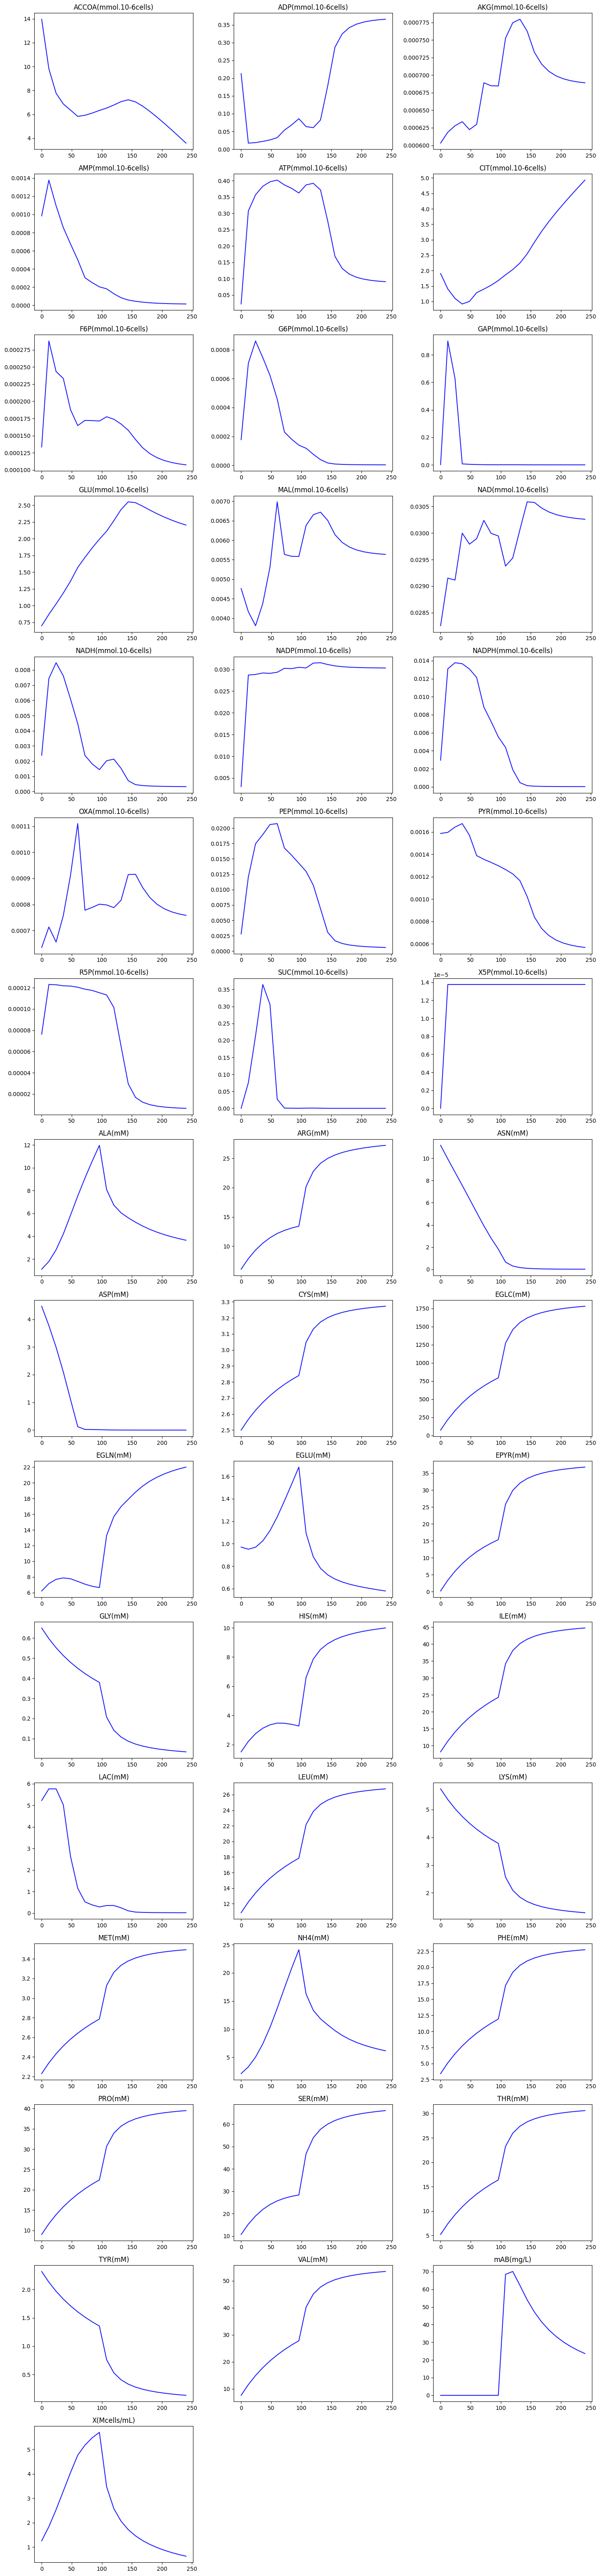

In [6]:
#add time label
from turtle import color


time_label = "t(h)"

#labels of state variables (ODEs), only external components are used
inputs_labels = ['X(Mcells/mL)', 'mAB(mg/L)', 'ALA(mM)', 'ARG(mM)', 'ASN(mM)', 'ASP(mM)', 'CYS(mM)', 'EGLC(mM)', 'EGLN(mM)', 'EGLU(mM)', 'EPYR(mM)', 'GLY(mM)', 'HIS(mM)',
                  'ILE(mM)', 'LAC(mM)', 'LEU(mM)', 'LYS(mM)','MET(mM)', 'NH4(mM)', 'PHE(mM)', 'PRO(mM)', 'SER(mM)', 'THR(mM)', 'TYR(mM)', 'VAL(mM)'] #mmol/L, except X (Mcells/mL) and mAB (mg/L)
inputs_labels = state_labels

n_cols = 3

n_species = len(inputs_labels)
n_rows = math.ceil(n_species / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  

for species_idx, species_name in enumerate(inputs_labels):
    ax = axes[species_idx]
    ax.plot(t, sol.y[species_idx], label='True', color='blue', alpha=0.90)
    ax.set_title(species_name)

for i in range(n_species, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
